In [1]:
import kagglehub
path = kagglehub.dataset_download("aayushmishra1512/twitchdata")
print("Path to dataset files:", path)

c:\Users\asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\asus\.cache\kagglehub\datasets\aayushmishra1512\twitchdata\versions\3


In [2]:
import pandas as pd
df = pd.read_csv('twitchdata-update.csv')
df

,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English
...,...,...,...,...,...,...,...,...,...,...,...
995,LITkillah,122524635,13560,21359,9104,601927,562691,2162107,True,False,Spanish
996,빅헤드 (bighead033),122523705,153000,3940,793,213212,52289,4399897,True,False,Korean
997,마스카 (newmasca),122452320,217410,6431,567,109068,-4942,3417970,True,False,Korean
998,AndyMilonakis,122311065,104745,10543,1153,547446,109111,3926918,True,False,English


C:\Users\asus\AppData\Local\Temp\ipykernel_19740\436551732.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_watch_time, y='Channel', x='Watch time(Minutes)', palette='Blues_r')


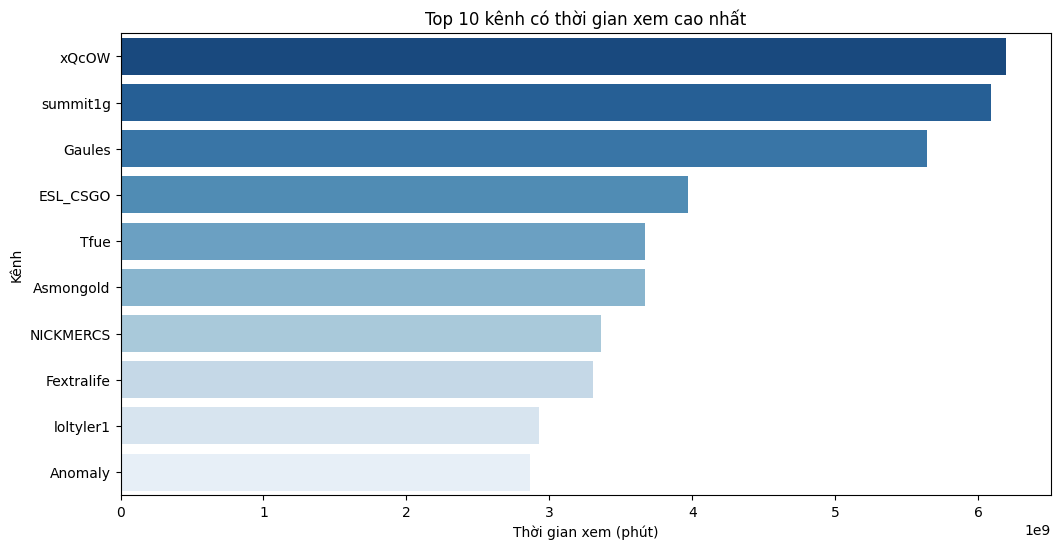

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

top_watch_time = df[['Channel', 'Watch time(Minutes)']].sort_values(
    by='Watch time(Minutes)', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_watch_time, y='Channel', x='Watch time(Minutes)', palette='Blues_r')
plt.title('Top 10 kênh có thời gian xem cao nhất')
plt.xlabel('Thời gian xem (phút)')
plt.ylabel('Kênh')
plt.show()




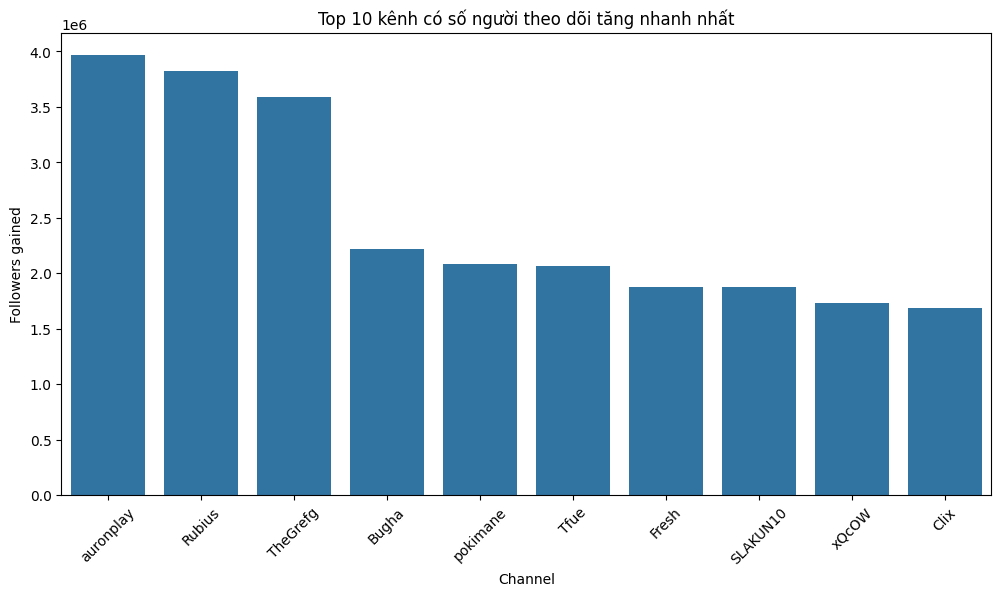

In [9]:
top_followers_gained = df[['Channel', 'Followers gained']].sort_values(
    by='Followers gained', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_followers_gained, x='Channel', y='Followers gained')
plt.xticks(rotation=45)
plt.title('Top 10 kênh có số người theo dõi tăng nhanh nhất')
plt.show()


In [11]:
df['Tỷ lệ tăng trưởng (%)'] = (df['Followers gained'] / df['Followers']) * 100


In [23]:
growth_rate = df[df['Followers'] > 0].sort_values(by='Tỷ lệ tăng trưởng (%)', ascending=False).head(10)

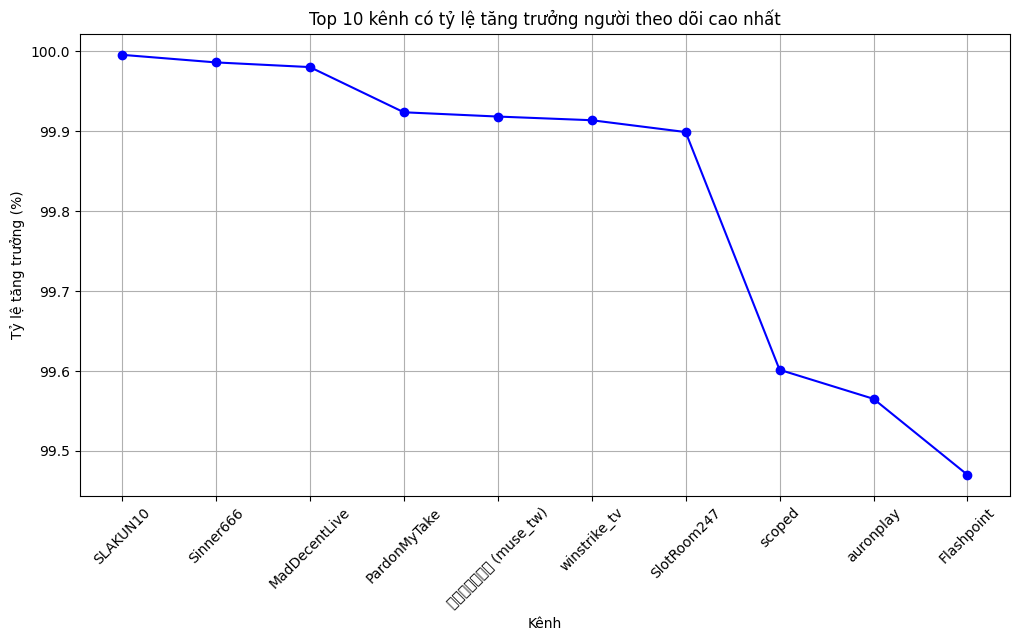

In [59]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 6))
plt.plot(growth_rate['Channel'], growth_rate['Tỷ lệ tăng trưởng (%)'], marker='o', linestyle='-', color='b')
plt.xticks(rotation=45)
plt.title('Top 10 kênh có tỷ lệ tăng trưởng người theo dõi cao nhất')
plt.xlabel('Kênh')
plt.ylabel('Tỷ lệ tăng trưởng (%)')
plt.grid(True)
plt.show()




In [31]:
top_channels = df.nlargest(2, 'Followers')[['Channel', 'Watch time(Minutes)', 'Views gained', 'Followers']]


C:\Users\asus\AppData\Local\Temp\ipykernel_52240\764885857.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_channels, x=top_channels.index, y='Watch time(Minutes)', palette='Blues')
C:\Users\asus\AppData\Local\Temp\ipykernel_52240\764885857.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_channels, x=top_channels.index, y='Views gained', palette='Greens')
C:\Users\asus\AppData\Local\Temp\ipykernel_52240\764885857.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_channels, x=top_channels.index, y='Followe

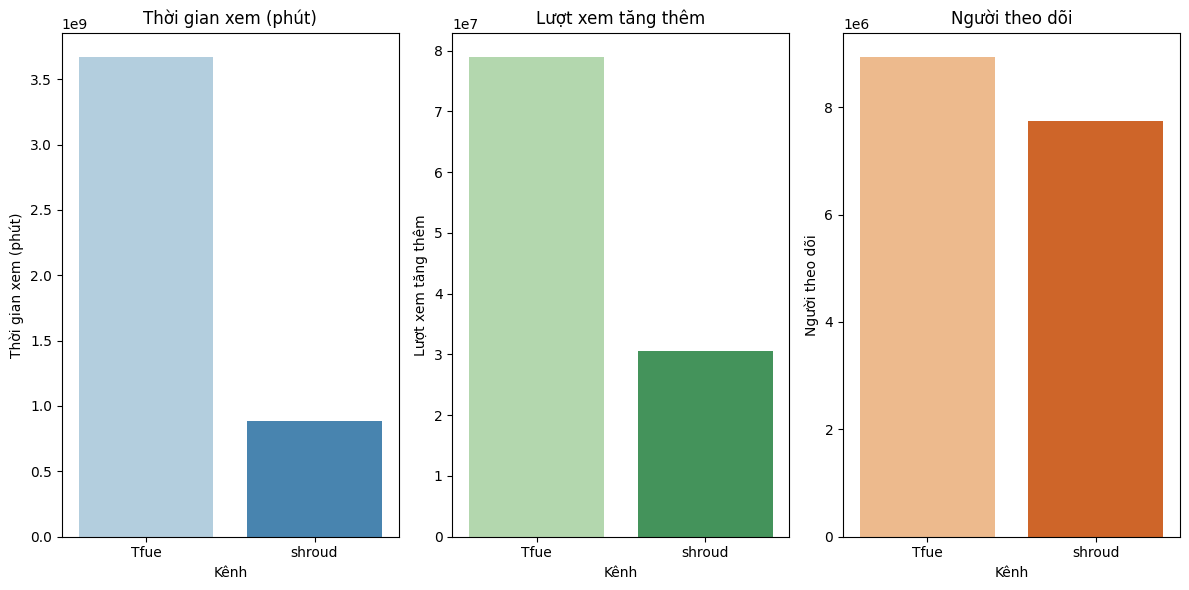

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
top_channels.set_index('Channel', inplace=True)
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.barplot(data=top_channels, x=top_channels.index, y='Watch time(Minutes)', palette='Blues')
plt.title('Thời gian xem (phút)')
plt.xlabel('Kênh')
plt.ylabel('Thời gian xem (phút)')
plt.subplot(1, 3, 2)
sns.barplot(data=top_channels, x=top_channels.index, y='Views gained', palette='Greens')
plt.title('Lượt xem tăng thêm')
plt.xlabel('Kênh')
plt.ylabel('Lượt xem tăng thêm')
plt.subplot(1, 3, 3)
sns.barplot(data=top_channels, x=top_channels.index, y='Followers', palette='Oranges')
plt.title('Người theo dõi')
plt.xlabel('Kênh')
plt.ylabel('Người theo dõi')

plt.tight_layout()
plt.show()




In [49]:
print(df.columns)


Index(['Channel', 'Watch time(Minutes)', 'Stream time(minutes)',
       'Peak viewers', 'Average viewers', 'Followers', 'Followers gained',
       'Views gained', 'Partnered', 'Mature', 'Language'],
      dtype='object')


C:\Users\asus\AppData\Local\Temp\ipykernel_52240\696294820.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=watch_time_data, x='Channel', y='Watch time(Minutes)', palette='viridis')


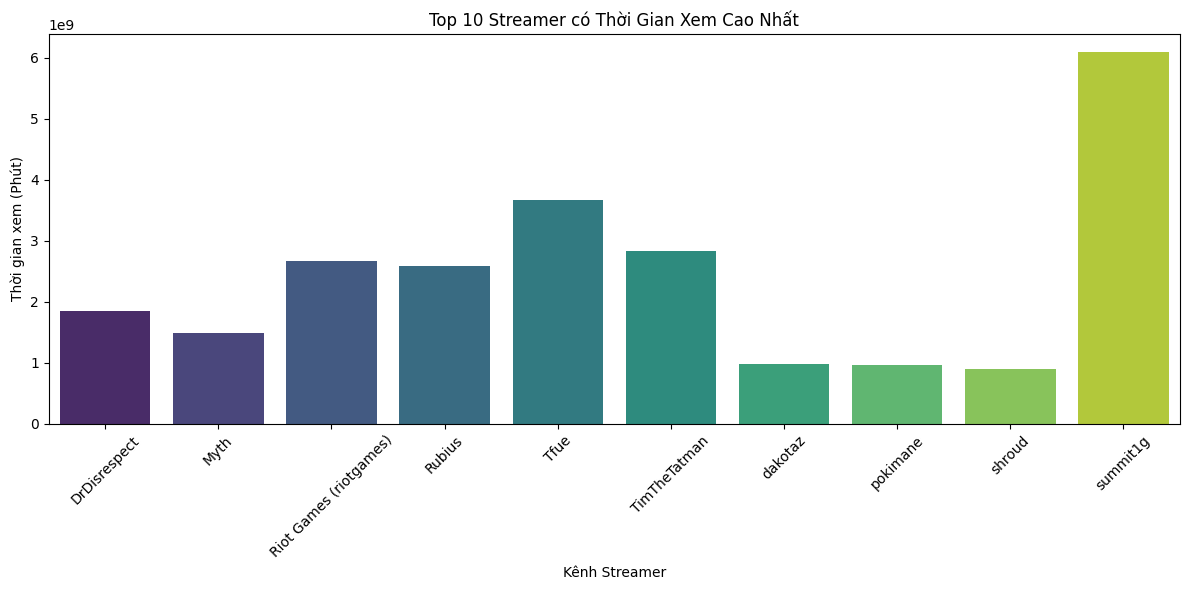

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top_streamers = df.sort_values(by='Followers', ascending=False).head(10)
watch_time_data = df[df['Channel'].isin(top_streamers['Channel'])].groupby('Channel').agg({
    'Watch time(Minutes)': 'sum'
}).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=watch_time_data, x='Channel', y='Watch time(Minutes)', palette='viridis')
plt.title('Top 10 Streamer có Thời Gian Xem Cao Nhất')
plt.xlabel('Kênh Streamer')
plt.ylabel('Thời gian xem (Phút)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [54]:
import pandas as pd
df['Growth Score'] = df['Followers'] / (df['Views gained'] + 1) * df['Watch time(Minutes)']
top_growth_channel = df.sort_values(by='Growth Score', ascending=False).head(1)
print("Kênh có khả năng phát triển nhanh nhất:")
print(top_growth_channel[['Channel', 'Growth Score']])


Kênh có khả năng phát triển nhanh nhất:
  Channel  Growth Score
4    Tfue  4.153835e+08


C:\Users\asus\AppData\Local\Temp\ipykernel_52240\63336538.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_growth_channels, x='Channel', y='Growth Score', palette='viridis')


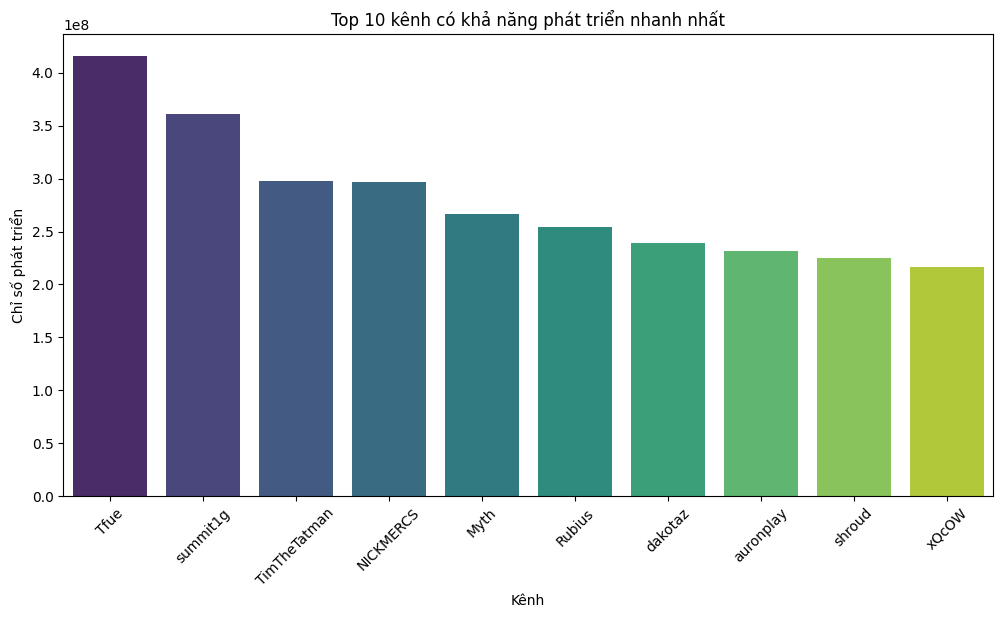

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df['Growth Score'] = df['Followers'] / (df['Views gained'] + 1) * df['Watch time(Minutes)']
top_growth_channels = df.sort_values(by='Growth Score', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_growth_channels, x='Channel', y='Growth Score', palette='viridis')
plt.title('Top 10 kênh có khả năng phát triển nhanh nhất')
plt.xlabel('Kênh')
plt.ylabel('Chỉ số phát triển')
plt.xticks(rotation=45)
plt.show()


In [56]:
df['Growth Rate (%)'] = (df['Followers gained'] / (df['Followers'] - df['Followers gained'])) * 100


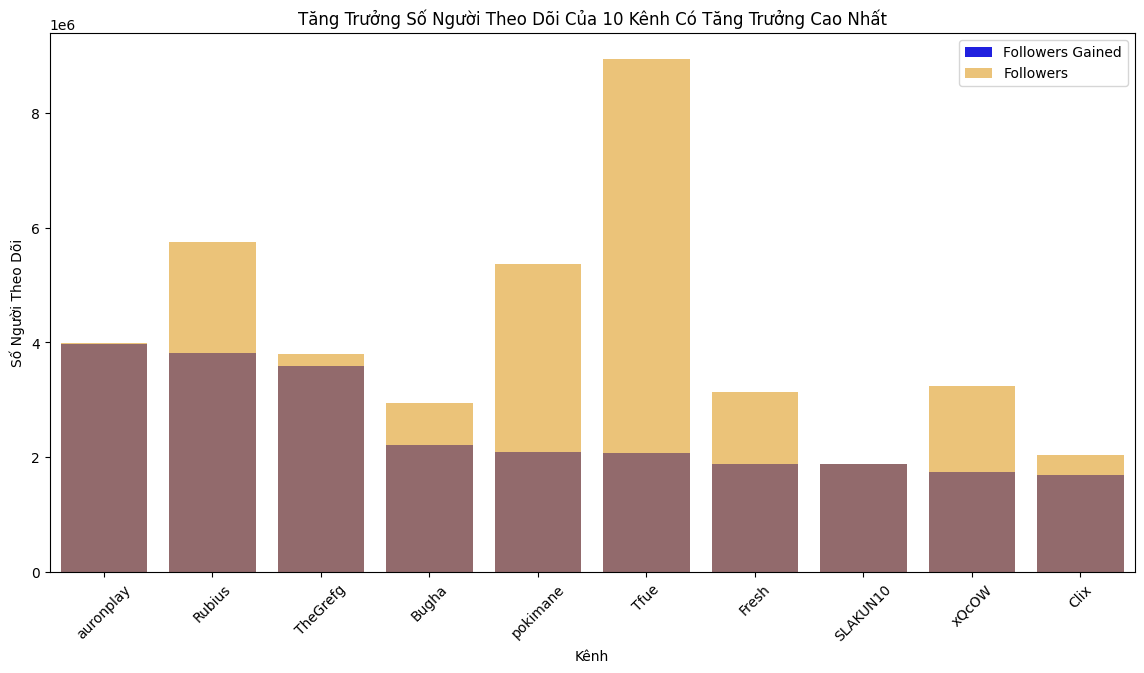

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
top_growth_channels = df.sort_values(by='Followers gained', ascending=False).head(10)
plt.figure(figsize=(14, 7))
sns.barplot(data=top_growth_channels, x='Channel', y='Followers gained', color='blue', label='Followers Gained')
sns.barplot(data=top_growth_channels, x='Channel', y='Followers', color='orange', label='Followers', alpha=0.6)

plt.title('Tăng Trưởng Số Người Theo Dõi Của 10 Kênh Có Tăng Trưởng Cao Nhất')
plt.xlabel('Kênh')
plt.ylabel('Số Người Theo Dõi')
plt.xticks(rotation=45)
plt.legend()
plt.show()
